<a href="https://colab.research.google.com/github/rah-ds/Cloud-Autoscaling-using-RL/blob/bmcgregor%2Fsimulator-refactor/notebooks/Experiment_Double_DQN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Experiment 2 - Double DQN

In [2]:
raw_url_dqn_agent = 'https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/Double_DQN_Agent.py'
local_filename_dqn_agent = 'Double_DQN_Agent.py'
!wget -O {local_filename_dqn_agent} {raw_url_dqn_agent}

--2025-11-24 00:54:57--  https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/Double_DQN_Agent.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3352 (3.3K) [text/plain]
Saving to: ‘Double_DQN_Agent.py’

Double_DQN_Agent.py 100%[===================>]   3.27K  --.-KB/s    in 0s      

2025-11-24 00:54:57 (63.9 MB/s) - ‘Double_DQN_Agent.py’ saved [3352/3352]



In [3]:

raw_url = 'https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/autoscaling_env.py'

# Replace with the desired local filename for your script
local_filename = 'autoscaling_env.py'

!wget -O {local_filename} {raw_url}

--2025-11-24 00:54:58--  https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/autoscaling_env.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8232 (8.0K) [text/plain]
Saving to: ‘autoscaling_env.py’

autoscaling_env.py  100%[===================>]   8.04K  --.-KB/s    in 0.001s  

2025-11-24 00:54:58 (13.2 MB/s) - ‘autoscaling_env.py’ saved [8232/8232]



In [4]:
raw_url_utilities = 'https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/DQN_Utils.py'
local_filename_utilities = 'DQN_Utils.py'
!wget -O {local_filename_utilities} {raw_url_utilities}

--2025-11-24 00:55:00--  https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/DQN_Utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4687 (4.6K) [text/plain]
Saving to: ‘DQN_Utils.py’

DQN_Utils.py        100%[===================>]   4.58K  --.-KB/s    in 0s      

2025-11-24 00:55:00 (70.6 MB/s) - ‘DQN_Utils.py’ saved [4687/4687]



In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd

df_usage = pd.read_csv('/content/drive/MyDrive/df_usage.csv')
display(df_usage.head())

,time_window,avg_cpu,avg_mem,active_machines
0,1970-01-01 00:05:00+00:00,0.006623,0.004912,9525
1,1970-01-01 00:06:00+00:00,0.003254,0.002733,3805
2,1970-01-01 00:07:00+00:00,0.003070,0.002770,4167
3,1970-01-01 00:08:00+00:00,0.001950,0.001823,4338
4,1970-01-01 00:09:00+00:00,0.001689,0.001468,5545


In [7]:
import sys
# Add the current directory to the system path to ensure Colab can find your local .py files
sys.path.append('.')


Episode 10	Average Score: -40433.38
Episode 20	Average Score: -9497.28
Episode 30	Average Score: -11285.92
Episode 40	Average Score: -5811.25
Episode 50	Average Score: -4867.81
Episode 60	Average Score: -4561.94
Episode 70	Average Score: -3889.55
Episode 80	Average Score: -3334.02
Episode 90	Average Score: -3330.62
Episode 100	Average Score: -2992.61
Episode 110	Average Score: -2746.86
Episode 120	Average Score: -2783.11
Episode 130	Average Score: -2608.73
Episode 140	Average Score: -2715.65
Episode 150	Average Score: -2429.72
Episode 160	Average Score: -2457.04
Episode 170	Average Score: -2348.39
Episode 180	Average Score: -2377.09
Episode 190	Average Score: -2227.71
Episode 200	Average Score: -2331.02
Episode 210	Average Score: -2165.40
Episode 220	Average Score: -2135.79
Episode 230	Average Score: -2148.74
Episode 240	Average Score: -2164.63
Episode 250	Average Score: -2101.63
Episode 260	Average Score: -2108.97
Episode 270	Average Score: -2080.70
Episode 280	Average Score: -2043.03

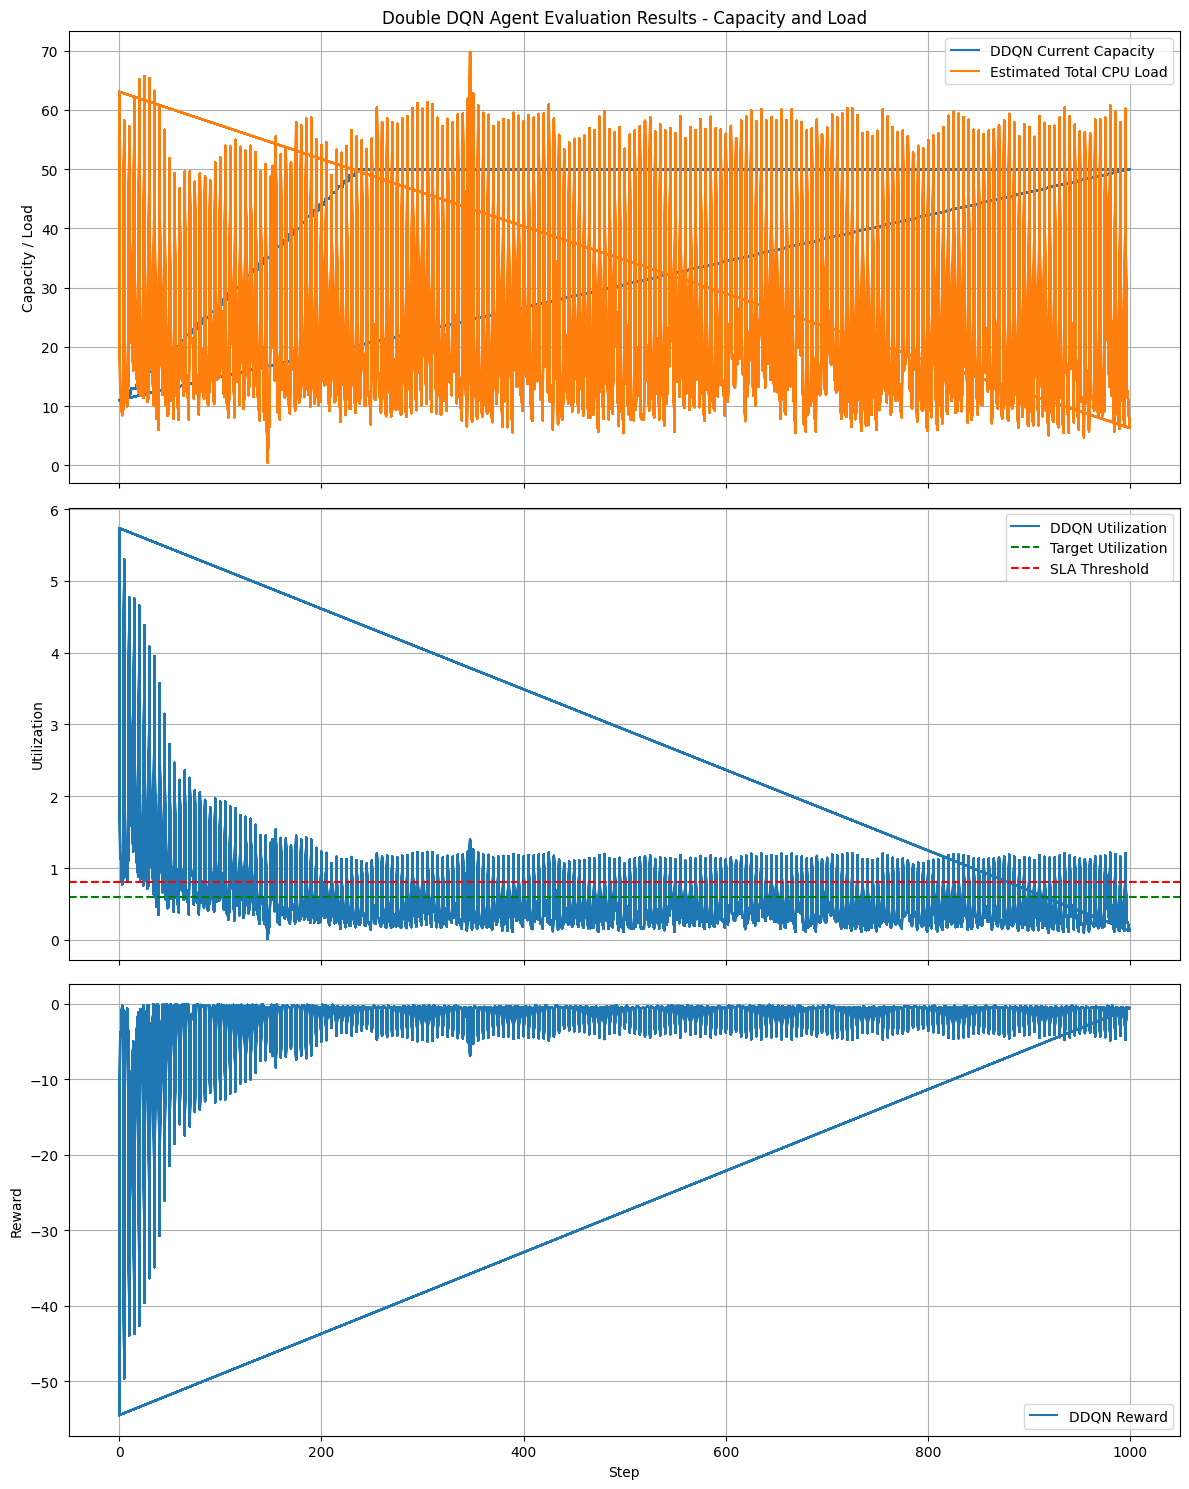

In [8]:
from DQN_Utils import train_agent, evaluate_agent, QNetwork, ReplayBuffer
from Double_DQN_Agent import DoubleDQNAgent
from autoscaling_env import AutoScalingEnv
import numpy as np
import sys
import matplotlib.pyplot as plt # Import missing plt for plotting
import torch # Import torch to define the device


# 1. Initialize the AutoScalingEnv environment for the Double DQN agent
env_ddqn = AutoScalingEnv(df_usage)

# 2. Instantiate the DoubleDQNAgent
agent_ddqn = DoubleDQNAgent(
    observation_space_shape=env_ddqn.observation_space.shape,
    action_space_size=env_ddqn.action_space.n,
    seed=0
)

# 3. Define the training hyperparameters for the Double DQN agent
num_episodes_ddqn = 500
max_steps_per_episode_ddqn = 1000
epsilon_start_ddqn = 1.0
epsilon_end_ddqn = 0.01
epsilon_decay_ddqn = 0.995

# 4. Call the train_agent function
ddqn_training_scores = train_agent(
    agent_ddqn,
    env_ddqn,
    num_episodes_ddqn,
    max_steps_per_episode_ddqn,
    epsilon_start_ddqn,
    epsilon_end_ddqn,
    epsilon_decay_ddqn
)

# 5. Print the first 5 scores from ddqn_training_scores
print("DDQN Training Scores:", ddqn_training_scores[:5])

# 6. Define the evaluation hyperparameters for the Double DQN agent
num_evaluation_episodes_ddqn = 10
max_steps_per_evaluation_episode_ddqn = 1000

# 7. Call the evaluate_agent function
ddqn_eval_scores, evaluation_results_df_ddqn = evaluate_agent(
    agent_ddqn,
    env_ddqn,
    num_evaluation_episodes_ddqn,
    max_steps_per_evaluation_episode_ddqn
)

# 8. Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 15), sharex=True)

# 9. Plot Current Capacity and Estimated Total CPU Load
axes[0].plot(evaluation_results_df_ddqn.index, evaluation_results_df_ddqn['current_capacity'], label='DDQN Current Capacity')
axes[0].plot(evaluation_results_df_ddqn.index, evaluation_results_df_ddqn['estimated_total_cpu_load'], label='Estimated Total CPU Load')
axes[0].set_ylabel('Capacity / Load')
axes[0].set_title('Double DQN Agent Evaluation Results - Capacity and Load')
axes[0].legend()
axes[0].grid(True)

# 10. Plot Utilization and Target Utilization
axes[1].plot(evaluation_results_df_ddqn.index, evaluation_results_df_ddqn['utilization'], label='DDQN Utilization')
axes[1].axhline(y=env_ddqn.target_utilization, color='g', linestyle='--', label='Target Utilization')
axes[1].axhline(y=env_ddqn.sla_threshold, color='r', linestyle='--', label='SLA Threshold')
axes[1].set_ylabel('Utilization')
axes[1].legend()
axes[1].grid(True)

# 11. Plot Reward
axes[2].plot(evaluation_results_df_ddqn.index, evaluation_results_df_ddqn['reward'], label='DDQN Reward')
axes[2].set_xlabel('Step')
axes[2].set_ylabel('Reward')
axes[2].legend()
axes[2].grid(True)

# 12. Adjust layout and display plots
plt.tight_layout()
plt.show()

## Double DQN Agent Performance Summary

**Training Results:**
*   The agent trained for 500 episodes. The training scores show a significant improvement over time, with the average score per 10 episodes increasing (becoming less negative) from approximately -40433.38 at episode 10 to -1945.79 at episode 500. This indicates that the agent successfully learned and improved its policy during training.

**Evaluation Results:**
*   During evaluation, the agent achieved a consistent average score of -1862.92 across 10 episodes. The fact that the score was identical for all evaluation episodes suggests the agent has learned a stable and deterministic policy.
*   **Capacity and Load (Plot 1):** The first plot illustrates how the agent's `current_capacity` responded to the `estimated_total_cpu_load`. Ideally, the `current_capacity` should closely track the `estimated_total_cpu_load` to avoid under- or over-provisioning.
*   **Utilization (Plot 2):** The second plot shows the `utilization` relative to the `target_utilization` and `sla_threshold`. The agent's goal is to maintain utilization close to the target while staying above the SLA threshold to ensure service quality and resource efficiency.
*   **Reward (Plot 3):** The third plot displays the `reward` per step. In this autoscaling environment, a higher (less negative) reward indicates better performance, balancing resource costs and service level agreements.